# Introduction to Machine Learning: Deep Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 1: Neural Network Foundations and the Mathematics of Learning

---

## Setup (do not edit)

In [1]:
import pathlib
from typing import Tuple, Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Suppress TensorFlow warnings for cleaner output
tf.get_logger().setLevel("ERROR")

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("breast_cancer_nn.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "breast_cancer_nn.csv is missing from the lab directory. Please download it or ask the TA "
        "for assistance."
    )

## 1. Load and Explore the Dataset *(10 points)*

Write a function `load_data()` that reads `breast_cancer_nn.csv` into a `pandas.DataFrame`.
Store the shape of the DataFrame in a variable called **`q1_shape`**.

The dataset contains 30 features computed from digitized images of breast mass fine needle
aspirates, plus a `target` column (0 = malignant, 1 = benign).

In [2]:


def load_data() -> pd.DataFrame:
    """Load the Breast Cancer Wisconsin dataset from CSV.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the 30 features plus the target column.
    """
    
    # Read the CSV file from the path
    return pd.read_csv(_DATA_PATH)


# Compute the answer required by the autograder
q1_shape: Tuple[int, int] = load_data().shape

In [3]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(q1_shape, tuple), (
    "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
)
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (rows, cols). "
    "Make sure you're using .shape, not .shape[0]."
)
assert q1_shape[0] > 0 and q1_shape[1] > 0, (
    "Shape values must be positive. Is your CSV loading correctly?"
)
print(f"Dataset shape: {q1_shape}")

Dataset shape: (569, 31)


## 2. Prepare Features and Target *(10 points)*

Separate the dataset into:
- **`X`**: A DataFrame containing all feature columns (everything except `target`)
- **`y`**: A Series containing the `target` column

Store the number of features in **`q2_n_features`** (an integer).

In [4]:
df = load_data() 

# X = all feature columns, drop the 'target' column
X = df.drop(columns = 'target')

# y = just the 'target' column, as a series
y = df['target']

# number of features is the num of columns in X
q2_n_features = X.shape[1]


In [5]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_n_features, (int, np.integer)), (
    "q2_n_features must be an integer. Use X.shape[1] to get the number of columns."
)
assert q2_n_features > 0, (
    "Number of features must be positive. Did you create X correctly?"
)
assert "target" not in X.columns, (
    "The target column 'target' should not be in your feature matrix X. "
    "Use df.drop(columns='target') to remove it."
)
print(f"Number of features: {q2_n_features}")

Number of features: 30


## 3. Train/Validation/Test Split with Scaling *(10 points)*

Neural networks perform better when features are standardized (zero mean, unit variance).

1. Split the data into **training (60%)**, **validation (20%)**, and **test (20%)** sets.
   Use `random_state=RANDOM_STATE`.
2. Fit a `StandardScaler` on the **training data only**, then transform all three sets.

Store the row counts as a tuple **`q3_split_counts = (n_train, n_val, n_test)`**.

**Hint:** First split into train+val (80%) and test (20%), then split train+val into train (75%) and val (25%).

In [6]:
# first split off the test set (0.20) leaving 0.80 as train + val
X_trainval, X_test, y_trainval, y_test = train_test_split(
                X, y, test_size = 0.20, random_state = RANDOM_STATE
)

# Split trainval (the 0.80) into train (0.60 overall) and val (0.20 overall)
#   0.25 of the remaining 0.80 equals 0.20 of the original data: [25% * 80%] = 20%
X_train, X_val, y_train, y_val = train_test_split(
                X_trainval, y_trainval, test_size = 0.25, random_state = RANDOM_STATE
)

n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)


# transform all 3 sets
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Also overwrite the originals so both naming conventions work downstream
X_train, X_val, X_test = X_train_scaled, X_val_scaled, X_test_scaled

q3_split_counts = (n_train, n_val, n_test)



In [7]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(q3_split_counts, tuple), (
    "q3_split_counts must be a tuple like (n_train, n_val, n_test)."
)
assert len(q3_split_counts) == 3, "Tuple should have exactly 3 elements."
n_train, n_val, n_test = q3_split_counts
assert all(n > 0 for n in q3_split_counts), (
    "All splits must have positive row counts."
)
assert n_train > n_val and n_train > n_test, (
    "Training set should be the largest. Check your split ratios."
)
print(f"Train/Val/Test split: {n_train} / {n_val} / {n_test}")

Train/Val/Test split: 341 / 114 / 114


## 4. Build a Neural Network Model *(10 points)*

Using Keras, build a neural network with the following architecture:
- **Input shape:** `(n_features,)` where `n_features` is from Question 2
- **Hidden Layer 1:** 16 neurons with ReLU activation
- **Hidden Layer 2:** 8 neurons with ReLU activation
- **Output Layer:** 1 neuron with Sigmoid activation (for binary classification)

Store the model in a variable called **`model`** and the total number of trainable
parameters in **`q4_n_params`** (an integer).

**Hint:** Use `model.count_params()` to get the parameter count.

In [8]:
# build a aimple feedforward neural network for binary classification
model = Sequential([
    # Hidden layer 1: 16 neurons, Relu activation, takes in n_features input
    Dense(16, activation = 'relu', input_shape = (q2_n_features,)),
    # Hidden layer 2: 8 neurons, Relu activation
    Dense(8, activation = 'relu'),
    # Output Layer: 1 neuron, sigmoid activation for binary classification (0-1 probability)
    Dense(1, activation = 'sigmoid'), # <- trailing comma here to be able to add more layers later
])

# count total trainable parameters in the model
q4_n_params = model.count_params()



I0000 00:00:1789602237.014669   10922 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20865 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:38:00.0, compute capability: 8.9


In [9]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert isinstance(model, Sequential), (
    "model should be a Keras Sequential model. "
    "Did you use Sequential([...])?"
)
assert isinstance(q4_n_params, (int, np.integer)), (
    "q4_n_params must be an integer. Use model.count_params()."
)
assert q4_n_params > 0, (
    "Model should have trainable parameters. Did you add layers?"
)
assert len(model.layers) == 3, (
    "Model should have exactly 3 layers (2 hidden + 1 output). "
    "Check your architecture."
)
print(f"Total trainable parameters: {q4_n_params}")

Total trainable parameters: 641


## 5. Compile and Train the Model *(10 points)*

1. **Compile** the model with:
   - Optimizer: `'adam'`
   - Loss: `'binary_crossentropy'`
   - Metrics: `['accuracy']`

2. **Train** the model for **50 epochs** with `batch_size=32` using the training data
   and validation data. Set `verbose=0` to suppress output.

Store the training history object in **`history`** and the final training accuracy
(last epoch) in **`q5_final_train_acc`** (float, rounded to 3 decimals).

In [10]:
# Compile the model with adam optomizer, binary crossentropy loss (this is appropriate for binary
#     classification) and 'accuracy' as the metric
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy'],
)


history = model.fit(
    X_train, y_train.values.astype(np.float32),
    validation_data = (X_val, y_val.values.astype(np.float32)),
    epochs = 50,
    batch_size = 32, 
    verbose = 0,
)


q5_final_train_acc = round(float(history.history['accuracy'][-1]), 3)

I0000 00:00:1789602239.423706   11130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [11]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert hasattr(history, 'history'), (
    "history should be a Keras History object. Did you call model.fit()?"
)
assert 'accuracy' in history.history, (
    "History should contain 'accuracy'. Did you include metrics=['accuracy'] in compile?"
)
assert 'val_accuracy' in history.history, (
    "History should contain 'val_accuracy'. Did you pass validation_data to fit()?"
)
assert isinstance(q5_final_train_acc, float), (
    "q5_final_train_acc must be a float."
)
assert 0 <= q5_final_train_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
print(f"Final training accuracy: {q5_final_train_acc:.3f}")

Final training accuracy: 0.988


## 6. Plot Training Curves *(10 points)*

Create a figure with **two subplots** side by side:
1. **Left subplot:** Training and validation **loss** over epochs
2. **Right subplot:** Training and validation **accuracy** over epochs

Both plots should include:
- X-axis label: "Epoch"
- Y-axis labels: "Loss" and "Accuracy" respectively
- Legend showing "Train" and "Validation"

Store the matplotlib figure object in **`q6_fig`**.

**Note:** Looking at these curves helps identify overfitting (when validation loss
increases while training loss continues to decrease).

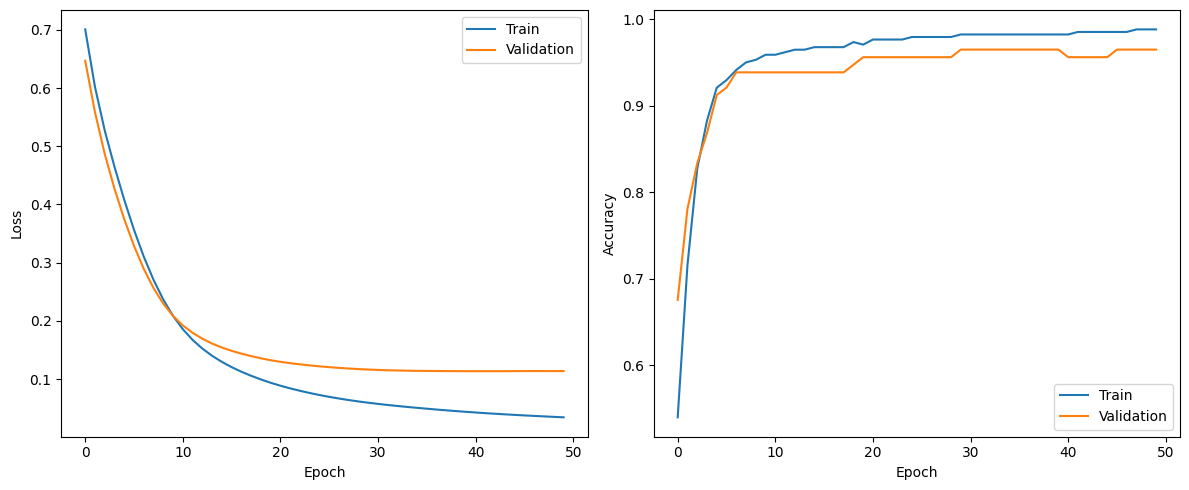

In [12]:
# create a figure w/ 2 subplots side by side: left - loss, right - accuracy
q6_fig, axes = plt.subplots(1, 2, figsize = (12, 5))

#left subplot: training vs validation loss over epochs
axes[0].plot(history.history['loss'], label = 'Train')
axes[0].plot(history.history['val_loss'], label = 'Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

#Right subplot: training vs validation accuracy over epoxh
axes[1].plot(history.history['accuracy'], label = 'Train')
axes[1].plot(history.history['val_accuracy'], label = 'Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [13]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert isinstance(q6_fig, plt.Figure), (
    "q6_fig must be a matplotlib Figure object. "
    "Use fig, axes = plt.subplots(...) and store fig in q6_fig."
)
assert len(q6_fig.axes) == 2, (
    "Figure should have exactly 2 subplots (loss and accuracy)."
)
print("Training curves plotted successfully!")

Training curves plotted successfully!


## 7. Evaluate on Test Set *(10 points)*

Evaluate the trained model on the **test set** (using the scaled test features).

Store the results as a tuple **`q7_test_metrics = (test_loss, test_accuracy)`**
with both values rounded to **3 decimals**.

In [14]:
# Eval the model on the scaled test set: returns [loss, acc]
test_loss, test_acc = model.evaluate(X_test, y_test, verbose = 0)

# round both vals to 3 decimal and store as tuple
q7_test_metrics = (round(float(test_loss), 3), round(float(test_acc), 3))

In [15]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(q7_test_metrics, tuple), (
    "q7_test_metrics must be a tuple (loss, accuracy)."
)
assert len(q7_test_metrics) == 2, "Tuple should have exactly 2 elements."
test_loss, test_acc = q7_test_metrics
assert isinstance(test_loss, float) and isinstance(test_acc, float), (
    "Both loss and accuracy must be floats."
)
assert test_loss >= 0, "Loss must be non-negative."
assert 0 <= test_acc <= 1, "Accuracy must be between 0 and 1."
print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {test_acc:.3f}")

Test Loss: 0.068, Test Accuracy: 0.956


## 8. Manual Forward Pass Function *(15 points)*

To reinforce your understanding of neural network mathematics, implement a function
that performs a **forward pass manually using NumPy**.

Implement **`manual_forward_pass(X: np.ndarray, weights: List) -> np.ndarray`** that:
1. Takes input data `X` (shape: n_samples × n_features)
2. Takes `weights` from `model.get_weights()` (a list of weight matrices and bias vectors)
3. Applies the forward pass through all layers:
   - For hidden layers: `Z = X @ W + b`, then `A = ReLU(Z)` where ReLU(x) = max(0, x)
   - For output layer: `Z = A @ W + b`, then `output = sigmoid(Z)`
4. Returns the final output probabilities

Store the predictions for the first 5 test samples in **`q8_manual_preds`** (shape: 5×1).

In [16]:
# make function
def manual_forward_pass(X: np.ndarray, weights: List) -> np.ndarray:
    '''Perfrom a forward pass thru the network manuaal using numpy
    Paramters: 
                X: np.ndarray - input data of shape (n_samples, n_features)
                weights: List - flat list of weight matrices and bias vectors [W1, b1. W2, b2...]
                
    Return:
                np.ndarray - final output probabilities, shape (n_samples, 1)
    '''
    def relu(z):
        return np.maximum(0, z)
    
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))
    
    A = np.asarray(X, dtype = np.float64)
    n_layers = len(weights) // 2  # Each layer contributes a W and a b (weight, bias)
    
    for i in range(n_layers):
        W = np.asarray(weights[2 * i], dtype = np.float64)
        b = np.asarray(weights[2 * i + 1], dtype = np.float64)
        Z = A @ W + b
        
        if i < n_layers - 1: 
            # Hidden layers use ReLU
            A = relu(Z)
        else: 
            # Output Layer uses sigmoid
            A = sigmoid(Z)
    
    return A

# get the trained weights from the Keras model
weights = model.get_weights()

# Run the manual forward pass on the first 5 test samples
q8_manual_preds = manual_forward_pass(X_test[:5], weights)

In [17]:
# If all tests pass (there might be hidden tests), you will earn 15 points
# Test Cell: Question 8
assert callable(manual_forward_pass), (
    "manual_forward_pass should be a callable function."
)
assert isinstance(q8_manual_preds, np.ndarray), (
    "q8_manual_preds must be a numpy array."
)
assert q8_manual_preds.shape == (5, 1), (
    f"q8_manual_preds should have shape (5, 1), got {q8_manual_preds.shape}. "
    "Make sure you're computing predictions for 5 samples with 1 output."
)
assert np.all((q8_manual_preds >= 0) & (q8_manual_preds <= 1)), (
    "Output probabilities must be between 0 and 1. Did you apply sigmoid to the output?"
)
print(f"Manual forward pass predictions (first 5):\n{q8_manual_preds.flatten()}")

Manual forward pass predictions (first 5):
[9.48801882e-01 1.99680856e-05 9.12474827e-04 9.99143666e-01
 9.99910216e-01]


## 9. Compare with Logistic Regression Baseline *(15 points)*

Train a `LogisticRegression` model (with `max_iter=1000` and `random_state=RANDOM_STATE`)
on the same scaled training data and evaluate it on the test set.

Store:
- **`q9_logreg_acc`**: Test accuracy of logistic regression (float, rounded to 3 decimals)
- **`q9_nn_better`**: Boolean indicating whether the neural network achieved higher
  test accuracy than logistic regression

**Note:** For simple datasets like this, logistic regression often performs comparably
to neural networks. Neural networks shine with more complex, high-dimensional data.

In [18]:
# Train a logistic regression model on the same scaled training data
logreg = LogisticRegression(max_iter = 1000, random_state = RANDOM_STATE)
logreg.fit(X_train, y_train)

# Eval on the test set
logreg_preds = logreg.predict(X_test)
q9_logreg_acc = round(float(accuracy_score(y_test, logreg_preds)), 3)

# Compare them, did the neural network do better than the logistic regression
q9_nn_better = q7_test_metrics[1] > q9_logreg_acc

In [19]:
# If all tests pass (there might be hidden tests), you will earn 15 points
# Test Cell: Question 9
assert isinstance(q9_logreg_acc, float), (
    "q9_logreg_acc must be a float."
)
assert 0 <= q9_logreg_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
assert isinstance(q9_nn_better, bool), (
    "q9_nn_better must be a boolean (True or False)."
)
print(f"Logistic Regression Test Accuracy: {q9_logreg_acc:.3f}")
print(f"Neural Network Test Accuracy: {q7_test_metrics[1]:.3f}")
print(f"Neural Network performed better: {q9_nn_better}")

Logistic Regression Test Accuracy: 0.982
Neural Network Test Accuracy: 0.956
Neural Network performed better: False


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.
